# V3 moneyness performance — 7-day monthly study

**This notebook is the computational source of truth.** The matching PDF is written from the same payload.

This report classifies the **same** option contracts as `V3_7d_hourly_empirical_study` into DOTM / OTM / ATM / ITM / DITM. It does not change filters, calibration, contracts, LSM settings, or the market benchmark.

| Item | Setting |
|------|---------|
| Models | GBM, GARCH, Heston, Merton, GARCH–Merton, Heston–Merton |
| Companies | SPY, AAPL, MSFT (pooled in both analyses) |
| Regimes | Crisis, Normal, Late-cycle, COVID (pooled in Analysis 1; separate in Analysis 2) |
| Contracts | Monday nearest-ATM listed calls from the main study (`n = 1224` per model) |
| Moneyness | `m = S/K` (calls) |
| Primary metric | RMSE% |
| Secondary | MAE, Bias $, **Bias%**, Early-exercise fraction |


## 0. Methodology

### Same design as the main study
7-day lookback, monthly recalibration, V3 filters (no-arbitrage, DTE 7–60, |S/K−1|≤10%, liquidity), Euler-corrected Heston, option-implied Heston NLS, LSM with 2,000 paths and seed 42. No look-ahead.

### Moneyness rule (calls)
Let `m = S/K`.

| Bucket | Rule |
|--------|------|
| DOTM | m < 0.98 |
| OTM | 0.98 ≤ m < 0.995 |
| ATM | 0.995 ≤ m ≤ 1.005 |
| ITM | 1.005 < m ≤ 1.02 |
| DITM | m > 1.02 |

These five bins partition the main-study 10% moneyness filter. The Monday ATM sampler concentrates mass in ATM.

### Metrics
- RMSE% = 100 × √ mean(((model − market)/market)²)
- Bias $ = mean(model − market)
- Bias% = 100 × mean((model − market)/market)
- BEST = lowest RMSE% among models with n > 0


In [1]:
import sys
from pathlib import Path
from IPython.display import display, HTML
ROOT = Path.cwd()
for cand in [ROOT, *ROOT.parents]:
    scripts = cand / 'V3-Models_result' / 'scripts'
    if scripts.exists():
        sys.path.insert(0, str(scripts))
        break
import run_v3_7d_hourly_moneyness_study as mx
panel = mx.load_panel()
payload = mx.build_payload(panel)
pdf = mx.write_pdf(payload)
print('n_overall', payload['n_overall'])
print('PDF', pdf)

## 1. Shared sample counts


In [1]:
display(HTML('counts'))

Regime,DOTM,OTM,ATM,ITM,DITM,Total
2022-10-21,0,9,19,28,46,102
2022-11-18,53,16,6,6,21,102
2022-12-16,37,18,19,14,14,102
2023-01-20,66,2,0,2,32,102
2023-02-17,59,20,7,2,14,102
2023-03-17,2,53,24,23,0,102
2023-04-21,38,32,19,10,3,102
2023-05-19,90,12,0,0,0,102
2023-06-16,102,0,0,0,0,102
2023-07-21,102,0,0,0,0,102


## 2. Analysis 1 — Overall moneyness


### Table M1. DOTM  ·  m < 0.98  ·  n = 753  ·  **BEST = Heston**


In [1]:
tab = payload['analysis1']['DOTM']
rows, header, best = mx._model_rows(tab['rows'])
display(HTML(mx._html_rows(rows, header, best)))

Model,n,RMSE%,MAE,Bias $,Bias%,Early-ex.,Mark
GBM,753,99.95,7.0573,-7.0573,-99.95,0.2%,
GARCH,753,99.92,7.0552,-7.0552,-99.92,0.4%,
Heston,753,98.34,6.9416,-6.9416,-98.25,2.3%,BEST
Merton,753,99.95,7.0572,-7.0572,-99.95,0.2%,
GARCH–Merton,753,99.91,7.0544,-7.0544,-99.90,0.4%,
Heston–Merton,753,98.34,6.9417,-6.9417,-98.25,2.2%,


### Table M2. OTM  ·  0.98 ≤ m < 0.995  ·  n = 162  ·  **BEST = Heston–Merton**


In [1]:
tab = payload['analysis1']['OTM']
rows, header, best = mx._model_rows(tab['rows'])
display(HTML(mx._html_rows(rows, header, best)))

Model,n,RMSE%,MAE,Bias $,Bias%,Early-ex.,Mark
GBM,162,97.86,6.8326,-6.8326,-97.83,6.4%,
GARCH,162,97.80,6.8243,-6.8243,-97.76,7.0%,
Heston,162,80.34,5.5982,-5.5982,-79.20,20.1%,
Merton,162,97.84,6.8317,-6.8317,-97.81,6.5%,
GARCH–Merton,162,97.45,6.8010,-6.8010,-97.40,7.5%,
Heston–Merton,162,80.22,5.5911,-5.5911,-79.08,19.9%,BEST


### Table M3. ATM  ·  0.995 ≤ m ≤ 1.005  ·  n = 94  ·  **BEST = Heston–Merton**


In [1]:
tab = payload['analysis1']['ATM']
rows, header, best = mx._model_rows(tab['rows'])
display(HTML(mx._html_rows(rows, header, best)))

Model,n,RMSE%,MAE,Bias $,Bias%,Early-ex.,Mark
GBM,94,86.98,6.3900,-6.3900,-86.62,34.2%,
GARCH,94,86.87,6.3710,-6.3710,-86.53,34.2%,
Heston,94,61.18,4.3230,-4.3230,-58.56,36.5%,
Merton,94,86.96,6.3887,-6.3887,-86.60,33.1%,
GARCH–Merton,94,86.15,6.3187,-6.3187,-85.79,32.7%,
Heston–Merton,94,61.06,4.3110,-4.3110,-58.45,35.9%,BEST


### Table M4. ITM  ·  1.005 < m ≤ 1.02  ·  n = 85  ·  **BEST = Heston–Merton**


In [1]:
tab = payload['analysis1']['ITM']
rows, header, best = mx._model_rows(tab['rows'])
display(HTML(mx._html_rows(rows, header, best)))

Model,n,RMSE%,MAE,Bias $,Bias%,Early-ex.,Mark
GBM,85,64.22,4.7075,-4.7075,-62.84,72.8%,
GARCH,85,64.29,4.7078,-4.7078,-62.94,73.2%,
Heston,85,43.27,3.0360,-3.0215,-39.60,51.9%,
Merton,85,64.14,4.7003,-4.7003,-62.75,68.3%,
GARCH–Merton,85,63.85,4.6733,-4.6733,-62.45,67.7%,
Heston–Merton,85,43.03,3.0186,-3.0073,-39.43,50.8%,BEST


### Table M5. DITM  ·  m > 1.02  ·  n = 130  ·  **BEST = GBM**


In [1]:
tab = payload['analysis1']['DITM']
rows, header, best = mx._model_rows(tab['rows'])
display(HTML(mx._html_rows(rows, header, best)))

Model,n,RMSE%,MAE,Bias $,Bias%,Early-ex.,Mark
GBM,130,51.91,3.2890,+0.0883,+6.06,91.2%,BEST
GARCH,130,52.02,3.2966,+0.0940,+6.15,90.7%,
Heston,130,54.66,3.2349,+0.8055,+15.59,74.8%,
Merton,130,52.05,3.3004,+0.1033,+6.28,88.1%,
GARCH–Merton,130,52.13,3.2993,+0.1072,+6.35,88.9%,
Heston–Merton,130,54.63,3.2260,+0.8142,+15.69,73.4%,


### Figure M1 — Model × Moneyness RMSE% heatmap


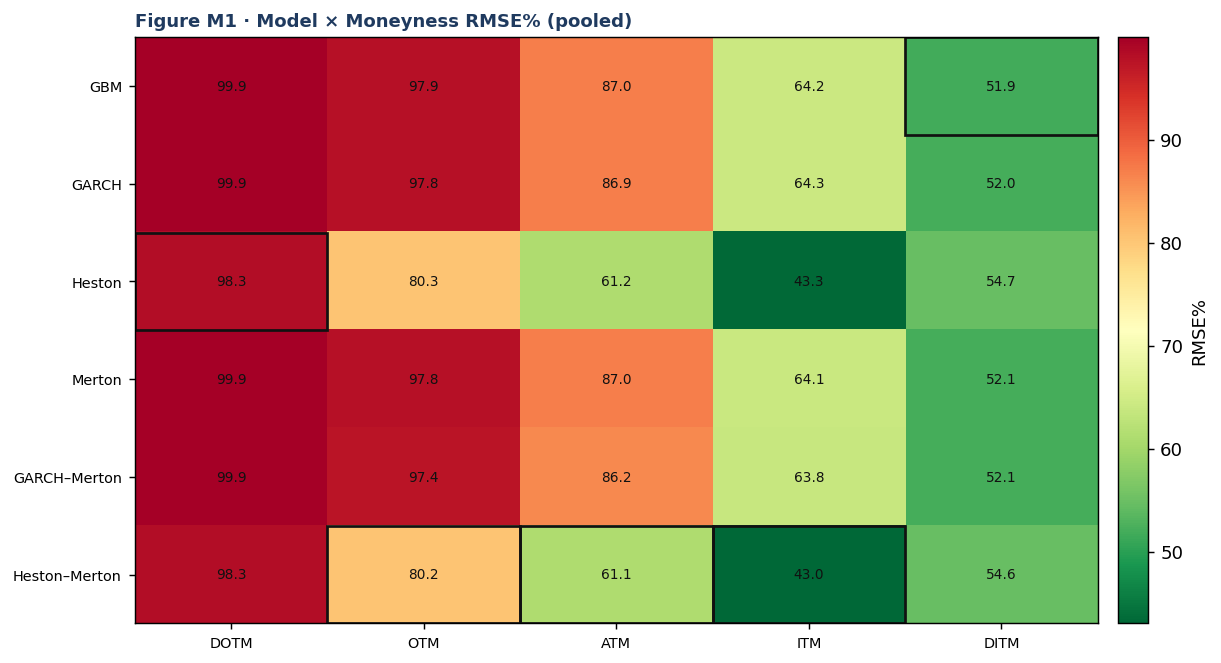

In [1]:
pass

## 3. Analysis 2 — Regime × moneyness


### Figure M2 — RMSE% heatmaps by regime


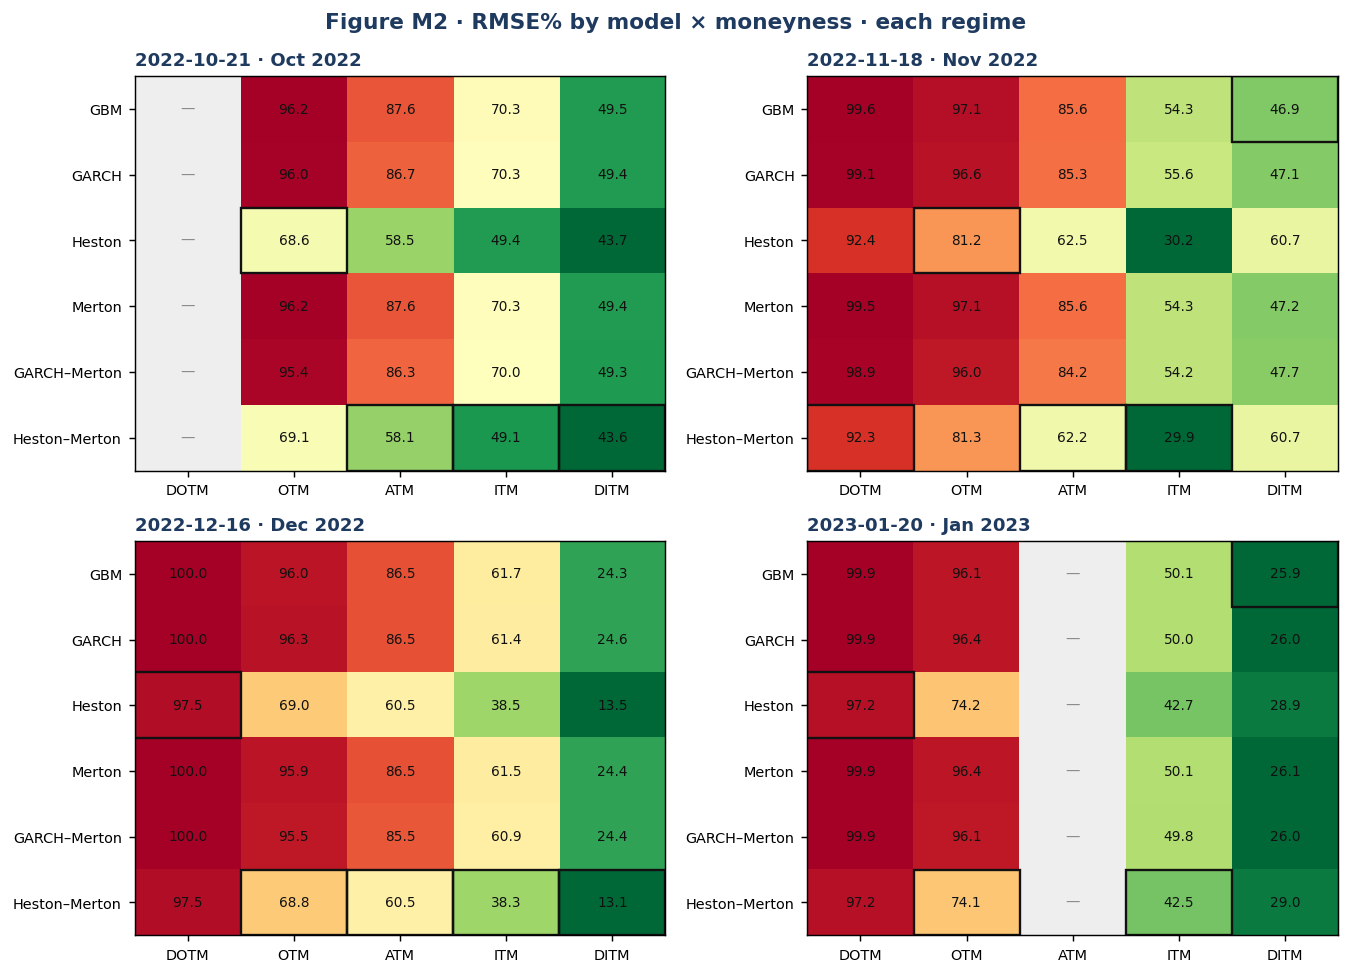

In [1]:
pass

### Table M6 — Best model by regime × moneyness


In [1]:
display(HTML('m6'))

Regime,DOTM,OTM,ATM,ITM,DITM
2022-10-21,—,Heston,Heston–Merton,Heston–Merton,Heston–Merton
2022-11-18,Heston–Merton,Heston,Heston–Merton,Heston–Merton,GBM
2022-12-16,Heston,Heston–Merton,Heston–Merton,Heston–Merton,Heston–Merton
2023-01-20,Heston,Heston–Merton,—,Heston–Merton,GBM
2023-02-17,Heston,Heston–Merton,Heston,Heston–Merton,GBM
2023-03-17,Heston–Merton,Heston–Merton,Heston,Heston–Merton,—
2023-04-21,Heston,Heston–Merton,Heston–Merton,Heston–Merton,Heston–Merton
2023-05-19,Heston–Merton,Heston–Merton,—,—,—
2023-06-16,Heston,—,—,—,—
2023-07-21,Heston,—,—,—,—


### Table M7 — n by regime × moneyness


In [1]:
display(HTML('m7'))

Regime,DOTM,OTM,ATM,ITM,DITM
2022-10-21,0,9,19,28,46
2022-11-18,53,16,6,6,21
2022-12-16,37,18,19,14,14
2023-01-20,66,2,0,2,32
2023-02-17,59,20,7,2,14
2023-03-17,2,53,24,23,0
2023-04-21,38,32,19,10,3
2023-05-19,90,12,0,0,0
2023-06-16,102,0,0,0,0
2023-07-21,102,0,0,0,0


## 4. Findings

- DOTM (n = 753): BEST = Heston with RMSE% = 98.34, Bias% = -98.25.

- OTM (n = 162): BEST = Heston–Merton with RMSE% = 80.22, Bias% = -79.08.

- ATM (n = 94): BEST = Heston–Merton with RMSE% = 61.06, Bias% = -58.45.

- ITM (n = 85): BEST = Heston–Merton with RMSE% = 43.03, Bias% = -39.43.

- DITM (n = 130): BEST = GBM with RMSE% = 51.91, Bias% = +6.06.

- Overall, the ranking does change with moneyness: DOTM → Heston, OTM → Heston–Merton, ATM → Heston–Merton, ITM → Heston–Merton, DITM → GBM.

- Inside regimes, the BEST model also changes with moneyness in: 2022-10-21, 2022-11-18, 2022-12-16, 2023-01-20, 2023-02-17, 2023-03-17, 2023-04-21.

- These comparisons use the hourly nearest-ATM sample (09:59–15:59; LSM skipped at Friday 15:59). ATM still holds most of the mass; sparse DOTM/DITM buckets should be read as descriptive.


## 5. Re-run

```python
import run_v3_7d_hourly_moneyness_study as mx
payload = mx.run()
```

Requires the main study contract CSVs under `V3-Models_result/results/empirical_study_7d_hourly/contracts/`.
